# 02 — EDA: Flood-It! 2 (`com.google.flood2`) — полный feature-вектор

## 0. Контекст

Это per-app EDA для **Flood-It! 2** (`com.google.flood2`), снятого с публикации Google Play Store в 2018-2019 годах. В отличие от Flood-It! (см. `02_eda_floodit.ipynb`), этот продукт является **кейсом провала** — его поведение на ранних метриках мы хотим уметь предсказывать.

**Что показывает этот ноутбук:**
- Полный feature-вектор Flood-It! 2 по 4 источникам
- Что характерно для провального продукта в product-метриках
- Почему store-сигнал отсутствует и что это значит
- Cross-source синтез — какие связи существуют (без store)

**Гипотеза:** провальный продукт идентифицируется ранними сигналами в product-метриках (нестабильный stickiness/retention/onboarding) и косвенно подтверждается отсутствием store-данных. Cross-source связи без store-канала — слабее, чем у успешного продукта.

**Структура:**
1. Контекст и загрузка
2. Качество данных по 4 источникам
3. Section A — Product (Firebase)
4. Section B — Store (отсутствует — нарратив провала)
5. Section C — Market (краткий референс)
6. Section D — External (краткий референс)
7. Cross-source synthesis на 40 признаках (без пустых store-колонок)
8. Объединённый time-series 5 ключевых метрик
9. Выводы для Flood-It! 2

In [1]:
import sys
from pathlib import Path

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
sys.path.insert(0, str(_ROOT))

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.feature_engineering import load_dataset, compute_vif
from notebooks._common import (
    APP_PALETTE, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
    split_by_app, top_correlated_pairs, check_inf_columns,
)

theme_setup()
np.random.seed(42)

NOTEBOOK_SLUG = "02_eda_floodit2"
APP_ID = "com.google.flood2"
df = load_dataset()
print(f"Dataset: {df.shape}")

Dataset: (222, 60)


In [2]:
PRODUCT_COLS = [
    "daily_installs", "daily_uninstalls", "net_installs",
    "dau", "mau", "wau", "stickiness",
    "retention_d1", "retention_d7", "retention_d30",
    "total_sessions", "median_session_duration", "avg_session_duration",
    "crash_rate", "onboarding_completion_rate", "peak_hour",
    "crash_rate_ma7", "avg_session_duration_ma7",
    "dau_growth_rate", "dau_growth_rate_7d", "install_growth_rate",
    "retention_d1_change", "retention_trend",
    "engagement_score",
]

STORE_COLS = [
    "rating", "reviews_count",
    "positive", "negative", "positive_ratio", "sentiment_score",
    "reviews_30d", "positive_30d", "negative_30d", "sentiment_30d",
    "rating_ma30", "positive_ratio_ma30",
    "rating_volatility_7d", "rating_trend", "negative_change",
    "downloads_index", "downloads_index_ma30",
]

MARKET_COLS = [
    "competitor_count", "category_rank",
    "competitor_count_change", "competition_volatility_7d",
    "category_rank_ma14", "category_rank_ma30",
    "rank_volatility_7d", "rank_improvement",
]

EXTERNAL_COLS = [
    "market_trend", "media_coverage",
    "market_sentiment", "media_coverage_ma7", "media_coverage_change",
    "seasonality_change",
]

SOURCE_GROUPS = {
    "Product": PRODUCT_COLS,
    "Store":   STORE_COLS,
    "Market":  MARKET_COLS,
    "External": EXTERNAL_COLS,
}
ALL_FEATURE_COLS = PRODUCT_COLS + STORE_COLS + MARKET_COLS + EXTERNAL_COLS
assert len(PRODUCT_COLS) == 24
assert len(STORE_COLS) == 17
assert len(MARKET_COLS) == 8
assert len(EXTERNAL_COLS) == 6
assert len(ALL_FEATURE_COLS) == 55
print(f"Group sizes: Product={len(PRODUCT_COLS)}, Store={len(STORE_COLS)}, "
      f"Market={len(MARKET_COLS)}, External={len(EXTERNAL_COLS)}")
print(f"Total feature cols: {len(ALL_FEATURE_COLS)}")

Group sizes: Product=24, Store=17, Market=8, External=6
Total feature cols: 55


## 1. Загрузка и общая структура

In [3]:
df_f1, df_f2 = split_by_app(df)
print(f"Flood-It! 2 shape: {df_f2.shape}")
print(f"Период: {df_f2['date'].min().date()} — {df_f2['date'].max().date()} "
      f"({(df_f2['date'].max() - df_f2['date'].min()).days + 1} дней)")
display(df_f2[["date"] + ALL_FEATURE_COLS[:5]].head())

Flood-It! 2 shape: (111, 60)
Период: 2018-06-12 — 2018-09-30 (111 дней)


,date,daily_installs,daily_uninstalls,net_installs,dau,mau
0,2018-06-12,12.0,0.0,12.0,315,315
1,2018-06-13,15.0,0.0,15.0,371,542
2,2018-06-14,20.0,0.0,20.0,361,693
3,2018-06-15,21.0,0.0,21.0,343,816
4,2018-06-16,16.0,0.0,16.0,309,924


In [4]:
# dtypes summary по source-группам
rows = []
for group, cols in SOURCE_GROUPS.items():
    sub = df_f2[cols]
    rows.append({
        "group": group,
        "n_cols": len(cols),
        "n_float": (sub.dtypes == "float64").sum(),
        "n_int": (sub.dtypes.isin(["int64", "int32"])).sum(),
        "total_nan": sub.isna().sum().sum(),
        "nan_pct": round(sub.isna().sum().sum() / sub.size * 100, 2),
    })
display(pd.DataFrame(rows))

,group,n_cols,n_float,n_int,total_nan,nan_pct
0,Product,24,20,0,290,10.89
1,Store,17,17,0,1665,88.24
2,Market,8,6,0,4,0.45
3,External,6,4,0,2,0.30


## 2. Качество данных по источникам

In [5]:
# NaN summary по группам
nan_per_col = df_f2[ALL_FEATURE_COLS].isna().sum()
nan_summary = []
for group, cols in SOURCE_GROUPS.items():
    sub = nan_per_col[cols]
    nan_summary.append({
        "group": group,
        "max_nan": int(sub.max()),
        "median_nan": int(sub.median()),
        "cols_with_nan": int((sub > 0).sum()),
        "total_cols": len(cols),
    })
display(pd.DataFrame(nan_summary))
print()
print("Топ-10 колонок по числу NaN у Flood-It! 2:")
display(nan_per_col.sort_values(ascending=False).head(10))

,group,max_nan,median_nan,cols_with_nan,total_cols
0,Product,98,0,9,24
1,Store,111,111,15,17
2,Market,1,0,4,8
3,External,1,0,2,6



Топ-10 колонок по числу NaN у Flood-It! 2:


reviews_30d             111
positive_ratio          111
sentiment_score         111
negative                111
positive                111
reviews_count           111
rating                  111
positive_30d            111
negative_change         111
rating_volatility_7d    111
dtype: int64

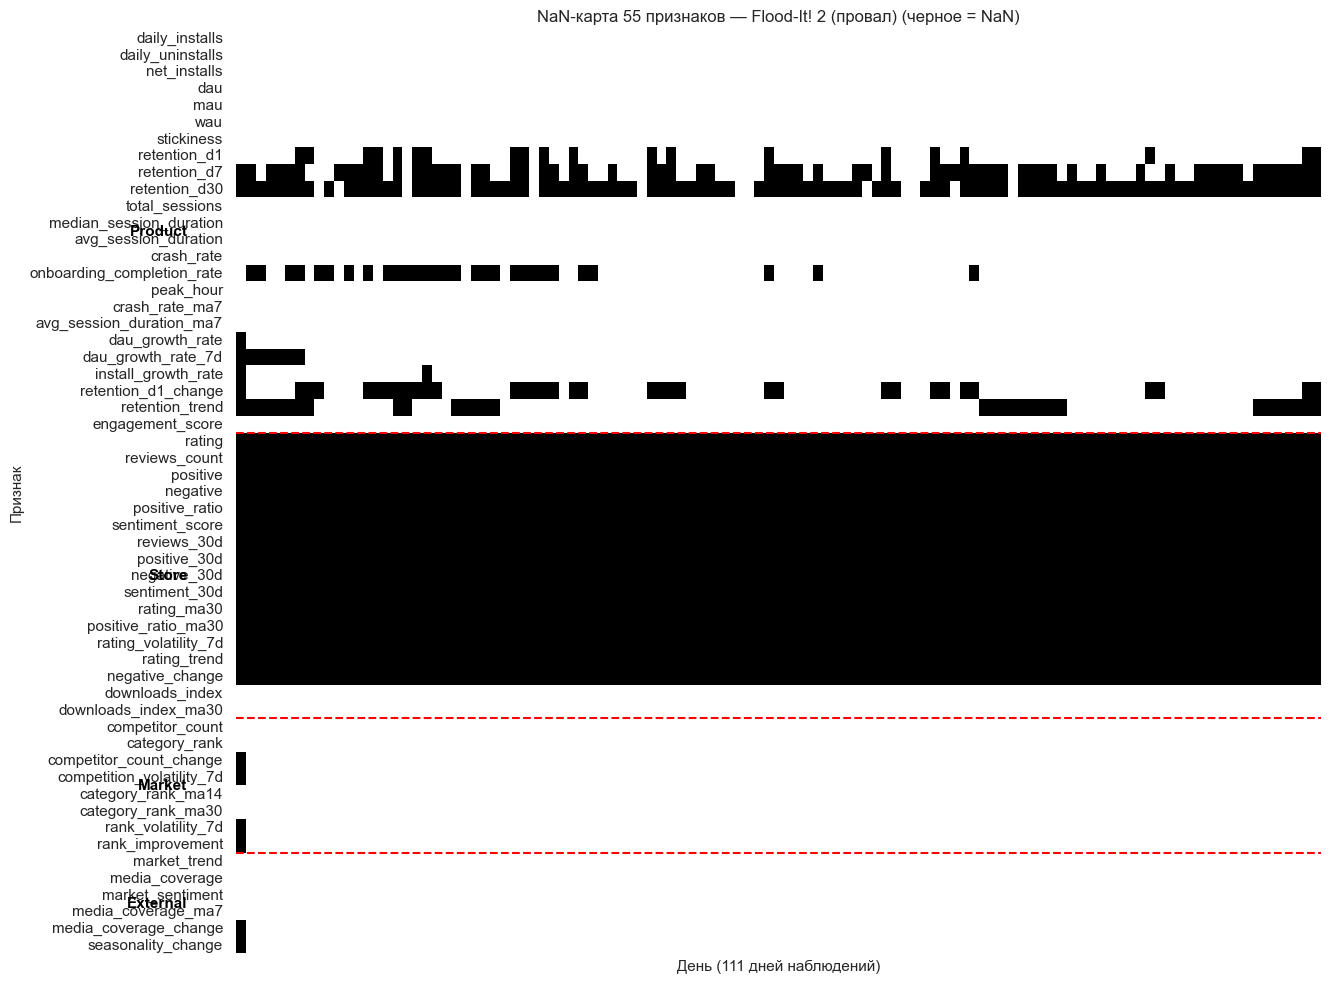

In [6]:
# NaN heatmap, grouped by source
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    df_f2[ALL_FEATURE_COLS].isna().T.astype(int),
    cmap="binary", cbar=False, xticklabels=False, ax=ax,
)
group_boundaries = [
    len(PRODUCT_COLS),
    len(PRODUCT_COLS) + len(STORE_COLS),
    len(PRODUCT_COLS) + len(STORE_COLS) + len(MARKET_COLS),
]
group_labels = ["Product", "Store", "Market", "External"]
group_starts = [0] + group_boundaries
for b in group_boundaries:
    ax.axhline(b, color="red", linewidth=1.5, linestyle="--")
for i, (start, label) in enumerate(zip(group_starts, group_labels)):
    end = group_boundaries[i] if i < len(group_boundaries) else len(ALL_FEATURE_COLS)
    mid = (start + end) / 2
    ax.text(-5, mid, label, fontsize=11, fontweight="bold",
            ha="right", va="center", color="black")
ax.set_title(f"NaN-карта 55 признаков — {app_label(APP_ID)} (черное = NaN)")
ax.set_ylabel("Признак")
ax.set_xlabel("День (111 дней наблюдений)")
save_figure("nan_heatmap", NOTEBOOK_SLUG)
plt.show()

In [7]:
inf_cols = check_inf_columns(df_f2, ALL_FEATURE_COLS)
if inf_cols:
    for c in inf_cols:
        n_inf = np.isinf(df_f2[c].dropna()).sum()
        print(f"  {c}: {n_inf} inf-значений")
else:
    print("inf-значений не найдено.")

⚠ inf-значения найдены в: ['install_growth_rate']
  → будут трактоваться как NaN при описательной статистике и моделировании.
  install_growth_rate: 4 inf-значений


In [8]:
# Sanity: процентные колонки в [0,1] (где есть данные)
PCT_COLS = ["stickiness", "retention_d1", "retention_d7", "retention_d30",
            "crash_rate", "onboarding_completion_rate", "positive_ratio"]
for col in PCT_COLS:
    s = df_f2[col].dropna()
    if len(s) == 0:
        print(f"{col}: нет валидных значений")
        continue
    in_range = (s >= 0).all() and (s <= 1).all()
    flag = "OK" if in_range else "OUT OF RANGE"
    print(f"{col}: [{s.min():.4f}, {s.max():.4f}] — {flag}")

stickiness: [0.0334, 1.0000] — OK
retention_d1: [0.0286, 0.6250] — OK
retention_d7: [0.0227, 0.2500] — OK
retention_d30: [0.0769, 0.2500] — OK
crash_rate: [0.0013, 0.1429] — OK
onboarding_completion_rate: [0.0625, 1.0000] — OK
positive_ratio: нет валидных значений


**NaN-стратегия:**

Для Flood-It! 2 ситуация принципиально иная: **15 из 17 store-колонок целиком пусты** (приложение снято с публикации, store API возвращает 404). Эти колонки исключаются из cross-source-анализа в §7. Остальная импутация (медианой) выполняется в `src/feature_engineering.py` перед VIF и моделированием.

## 3. Section A — Product (Firebase) для Flood-It! 2

In [9]:
display(df_f2[PRODUCT_COLS].describe().T.round(3))

C:\Users\Анастасия\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
daily_installs,111.0,12.505,7.861,0.000,8.000,11.000,16.000,44.000
daily_uninstalls,111.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
net_installs,111.0,12.505,7.861,0.000,8.000,11.000,16.000,44.000
dau,111.0,272.495,181.675,125.000,161.000,203.000,325.000,888.000
mau,111.0,2519.108,977.585,315.000,1629.000,2516.000,3376.500,4067.000
wau,111.0,1050.054,520.953,315.000,604.500,721.000,1480.000,2545.000
stickiness,111.0,0.136,0.136,0.033,0.062,0.107,0.139,1.000
retention_d1,91.0,0.231,0.124,0.029,0.125,0.222,0.326,0.625
retention_d7,44.0,0.119,0.060,0.023,0.077,0.106,0.147,0.250
retention_d30,13.0,0.123,0.053,0.077,0.083,0.100,0.143,0.250


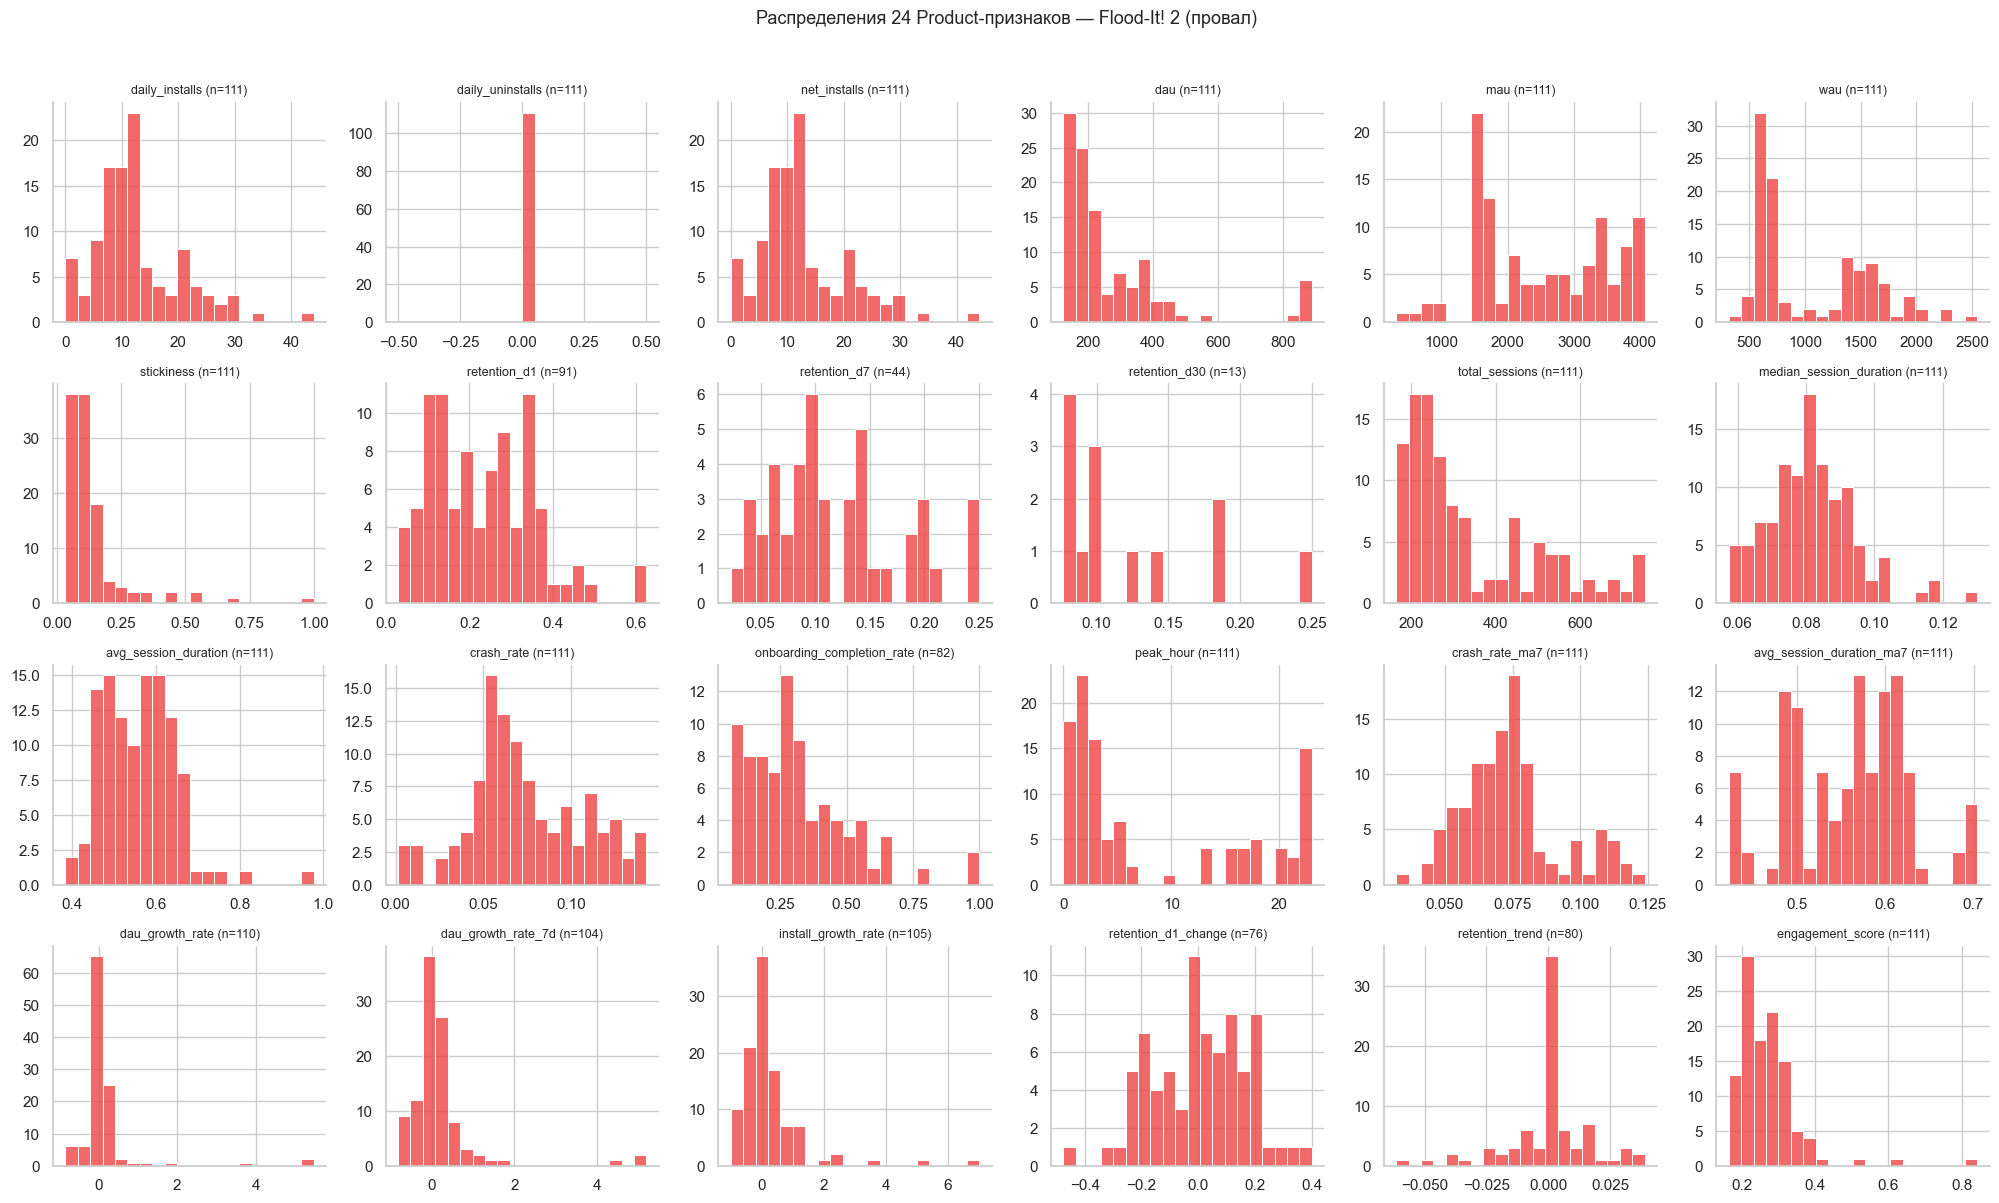

In [10]:
# Histograms grid 4×6 — single-color (красный = Flood-It! 2)
fig, axes = plt.subplots(4, 6, figsize=(20, 12))
for i, col in enumerate(PRODUCT_COLS):
    ax = axes.flat[i]
    s = df_f2[col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) > 0:
        sns.histplot(s, color=APP_PALETTE[APP_ID], bins=20, ax=ax, alpha=0.8, kde=False)
    ax.set_title(f"{col} (n={len(s)})", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle(f"Распределения 24 Product-признаков — {app_label(APP_ID)}", y=1.00, fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.98))
save_figure("histograms_product", NOTEBOOK_SLUG)
plt.show()

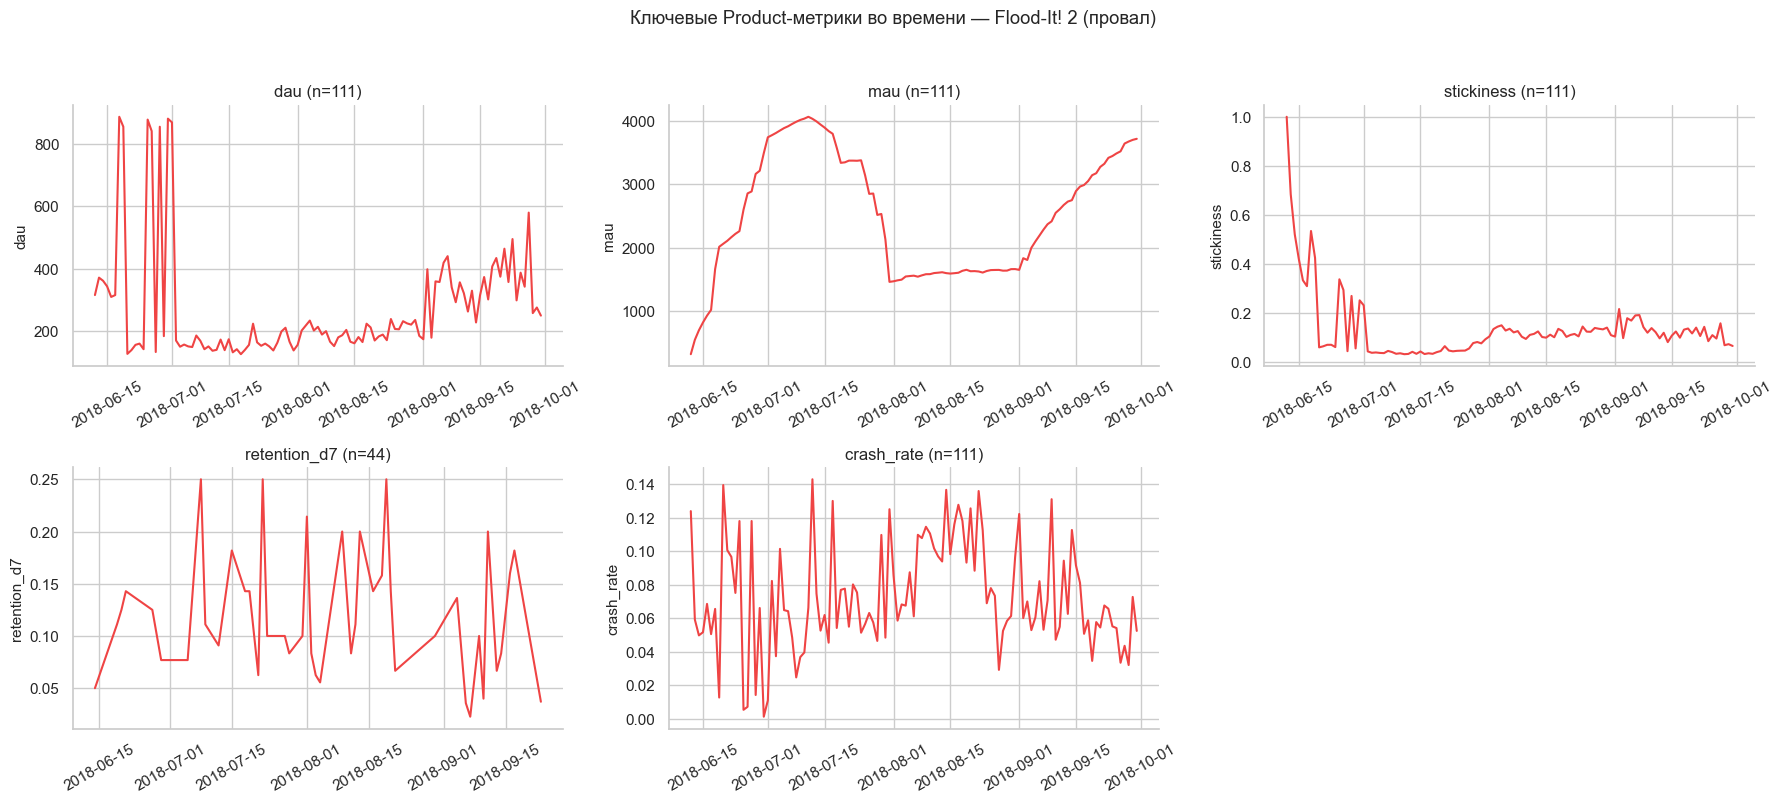

In [11]:
# Time series 5 ключевых
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
key_product = ["dau", "mau", "stickiness", "retention_d7", "crash_rate"]
for i, col in enumerate(key_product):
    ax = axes.flat[i]
    sns.lineplot(data=df_f2, x="date", y=col,
                 color=APP_PALETTE[APP_ID], ax=ax)
    ax.set_title(f"{col} (n={df_f2[col].notna().sum()})")
    ax.set_xlabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(30)
axes.flat[5].set_visible(False)
fig.suptitle(f"Ключевые Product-метрики во времени — {app_label(APP_ID)}", y=1.00)
plt.tight_layout(rect=(0, 0, 1, 0.97))
save_figure("timeseries_product", NOTEBOOK_SLUG)
plt.show()

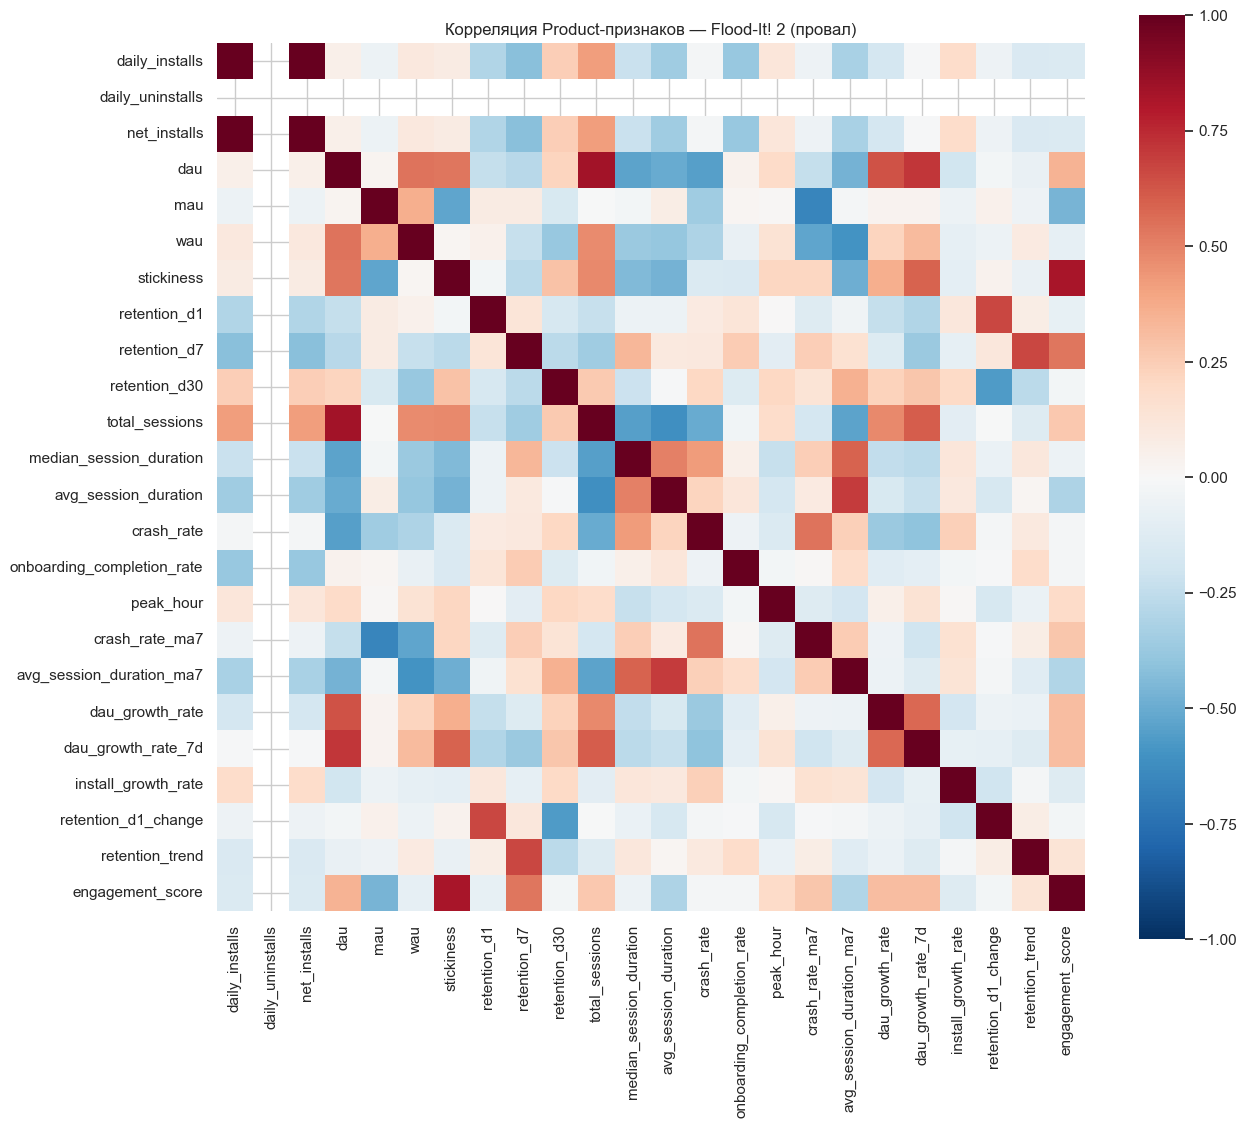

Топ-5 интра-Product пар |corr|>0.7:
daily_installs  net_installs          1.000000
dau             total_sessions        0.836445
stickiness      engagement_score      0.827206
dau             dau_growth_rate_7d    0.713471
dtype: float64


In [12]:
# Intra-source corr heatmap для Product
fig, ax = plt.subplots(figsize=(14, 12))
corr_product = df_f2[PRODUCT_COLS].corr()
sns.heatmap(corr_product, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=False, square=True, ax=ax)
ax.set_title(f"Корреляция Product-признаков — {app_label(APP_ID)}")
save_figure("corr_product", NOTEBOOK_SLUG)
plt.show()
print("Топ-5 интра-Product пар |corr|>0.7:")
print(top_correlated_pairs(corr_product, threshold=0.7, n=5))

## 4. Section B — Store метрики Flood-It! 2

### ⚠️ Все core-store-колонки = NaN

Flood-It! 2 был снят с публикации в Google Play в 2018-2019 годах. На дату snapshot store API возвращает 404. Соответственно:

- **15 «core» reputation-колонок** (rating, reviews_*, sentiment_*, MA-производные) = 100% NaN
- **2 DAU-derived колонки** (`downloads_index`, `downloads_index_ma30`) присутствуют —   они вычисляются из product-данных (DAU/MAU), а не из store API

**Само отсутствие store-сигнала — один из ранних индикаторов провала продукта.**
В моделирующих ноутбуках (`06_modeling_*`) это означает: store-feature-channel недоступен для f2, и модель должна полагаться на Product/Market/External каналы.

In [13]:
nan_pct_store = (df_f2[STORE_COLS].isna().mean() * 100).round(1)
display(nan_pct_store.to_frame("NaN %"))
print(f"\nКолонок с 100% NaN: {(nan_pct_store == 100.0).sum()}/{len(STORE_COLS)}")
print(f"Колонок с данными: {(nan_pct_store < 100.0).sum()}/{len(STORE_COLS)}")

,NaN %
rating,100.0
reviews_count,100.0
positive,100.0
negative,100.0
positive_ratio,100.0
sentiment_score,100.0
reviews_30d,100.0
positive_30d,100.0
negative_30d,100.0
sentiment_30d,100.0



Колонок с 100% NaN: 15/17
Колонок с данными: 2/17


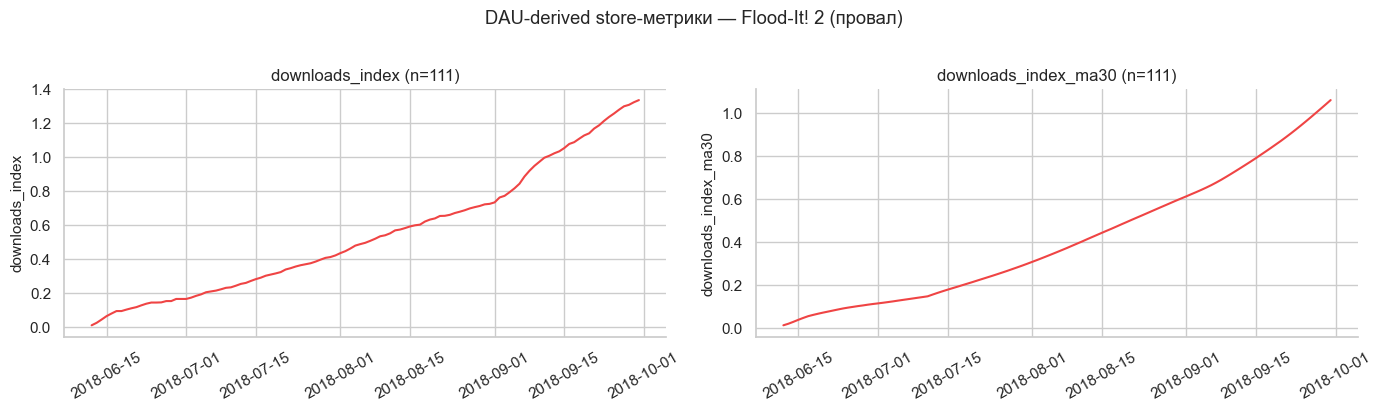

In [14]:
# Time-series для двух DAU-derived store-колонок (только они присутствуют)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, col in enumerate(["downloads_index", "downloads_index_ma30"]):
    sns.lineplot(data=df_f2, x="date", y=col, color=APP_PALETTE[APP_ID], ax=axes[i])
    axes[i].set_title(f"{col} (n={df_f2[col].notna().sum()})")
    axes[i].set_xlabel("")
    for label in axes[i].get_xticklabels():
        label.set_rotation(30)
fig.suptitle(f"DAU-derived store-метрики — {app_label(APP_ID)}", y=1.02)
plt.tight_layout()
save_figure("timeseries_store_partial", NOTEBOOK_SLUG)
plt.show()

## 5. Section C — Market (краткий референс)

Market-метрики (`competitor_count`, `category_rank`, их MA и волатильности) **общие для обоих приложений** — обе игры в одной категории Google Play (puzzle), и значения собираются для категории целиком, а не для отдельного приложения. Полный анализ Market-группы — в `01_source_market.ipynb`.

Здесь приводим только один time-series график для контекста: как меняется конкурентная среда у Flood-It! 2 за период наблюдений.

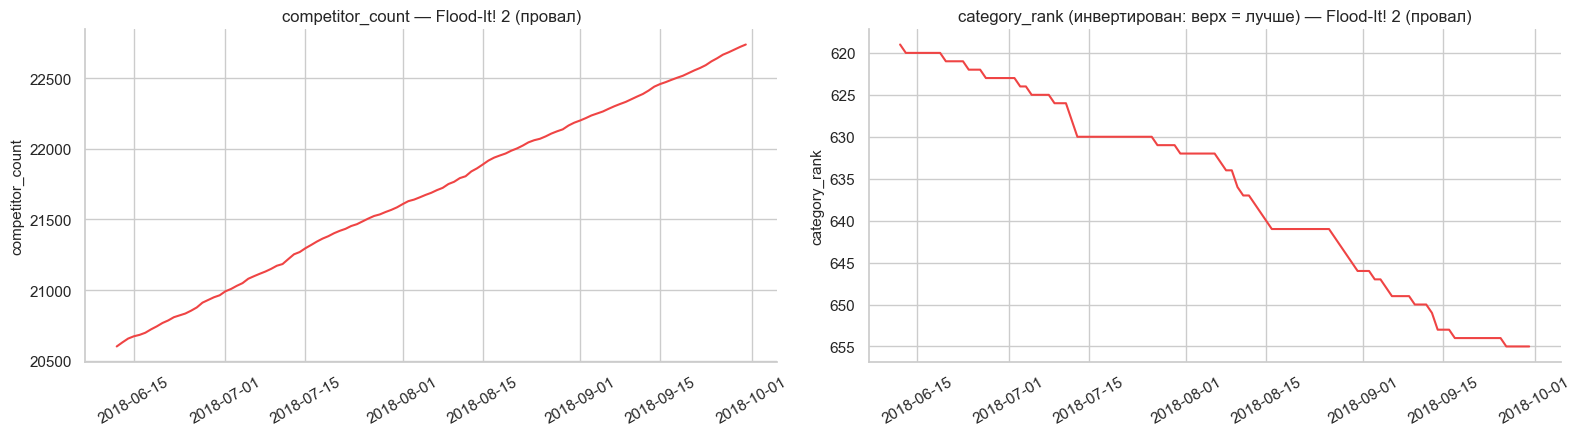

competitor_count: median=21688.0, std=620.40
category_rank: median=632.0, std=11.58


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.lineplot(data=df_f2, x="date", y="competitor_count",
             color=APP_PALETTE[APP_ID], ax=axes[0])
axes[0].set_title(f"competitor_count — {app_label(APP_ID)}")
axes[0].set_xlabel("")
sns.lineplot(data=df_f2, x="date", y="category_rank",
             color=APP_PALETTE[APP_ID], ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title(f"category_rank (инвертирован: верх = лучше) — {app_label(APP_ID)}")
axes[1].set_xlabel("")
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(30)
plt.tight_layout()
save_figure("timeseries_market_for_f2", NOTEBOOK_SLUG)
plt.show()
print(f"competitor_count: median={df_f2['competitor_count'].median()}, "
      f"std={df_f2['competitor_count'].std():.2f}")
print(f"category_rank: median={df_f2['category_rank'].median()}, "
      f"std={df_f2['category_rank'].std():.2f}")

## 6. Section D — External (краткий референс)

External-метрики (`market_trend`, `media_coverage`, `market_sentiment`, MA и change-производные) отражают **внешний фон рынка** — Google Trends, медиа-упоминания, сезонность. Эти значения общие для обоих приложений (рынок один). Полный анализ — в `01_source_external.ipynb`.

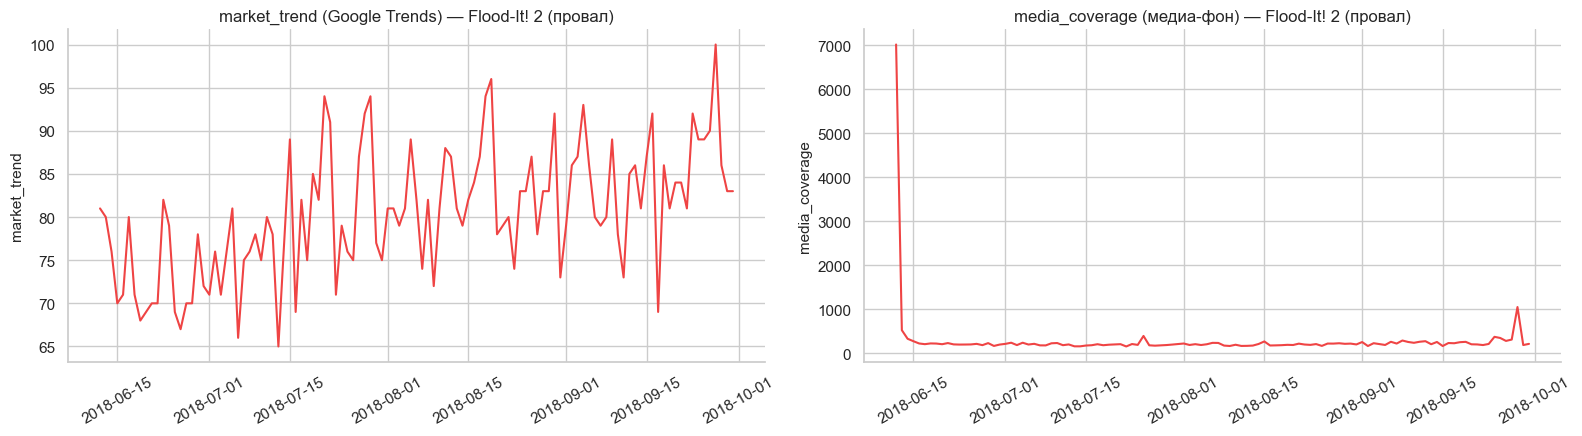

market_trend: median=81.000, std=7.384
media_coverage: median=205.000, std=651.920


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
sns.lineplot(data=df_f2, x="date", y="market_trend",
             color=APP_PALETTE[APP_ID], ax=axes[0])
axes[0].set_title(f"market_trend (Google Trends) — {app_label(APP_ID)}")
axes[0].set_xlabel("")
sns.lineplot(data=df_f2, x="date", y="media_coverage",
             color=APP_PALETTE[APP_ID], ax=axes[1])
axes[1].set_title(f"media_coverage (медиа-фон) — {app_label(APP_ID)}")
axes[1].set_xlabel("")
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_rotation(30)
plt.tight_layout()
save_figure("timeseries_external_for_f2", NOTEBOOK_SLUG)
plt.show()
print(f"market_trend: median={df_f2['market_trend'].median():.3f}, "
      f"std={df_f2['market_trend'].std():.3f}")
print(f"media_coverage: median={df_f2['media_coverage'].median():.3f}, "
      f"std={df_f2['media_coverage'].std():.3f}")

## 7. ⭐ Cross-source synthesis (на 40 непустых признаках)

У Flood-It! 2 15 store-колонок целиком пусты — корреляции на NaN не определены. Поэтому весь cross-source-анализ выполняется на **40 непустых признаках** (24 Product + 2 DAU-derived store + 8 Market + 6 External).

In [17]:
CORE_STORE_COLS_EMPTY = [c for c in STORE_COLS if df_f2[c].isna().all()]
DAU_DERIVED_STORE = [c for c in STORE_COLS if c not in CORE_STORE_COLS_EMPTY]
print(f"Store колонок 100% NaN (исключаем): {len(CORE_STORE_COLS_EMPTY)}")
print(f"  → {CORE_STORE_COLS_EMPTY}")
print(f"DAU-derived store колонок (включаем): {DAU_DERIVED_STORE}")

# 55 - 15 = 40 признаков
NON_EMPTY_FEATURES = [c for c in ALL_FEATURE_COLS if c not in CORE_STORE_COLS_EMPTY]
assert len(NON_EMPTY_FEATURES) == 40, len(NON_EMPTY_FEATURES)
print(f"\nCross-source анализ выполняется на {len(NON_EMPTY_FEATURES)} признаках (вместо 55)")

# Группа для Store-after-filter (только DAU-derived)
SOURCE_GROUPS_F2 = {
    "Product": PRODUCT_COLS,
    "Store":   DAU_DERIVED_STORE,
    "Market":  MARKET_COLS,
    "External": EXTERNAL_COLS,
}

Store колонок 100% NaN (исключаем): 15
  → ['rating', 'reviews_count', 'positive', 'negative', 'positive_ratio', 'sentiment_score', 'reviews_30d', 'positive_30d', 'negative_30d', 'sentiment_30d', 'rating_ma30', 'positive_ratio_ma30', 'rating_volatility_7d', 'rating_trend', 'negative_change']
DAU-derived store колонок (включаем): ['downloads_index', 'downloads_index_ma30']

Cross-source анализ выполняется на 40 признаках (вместо 55)


### 7.1. Полная корр. матрица 40×40 со source-разделителями

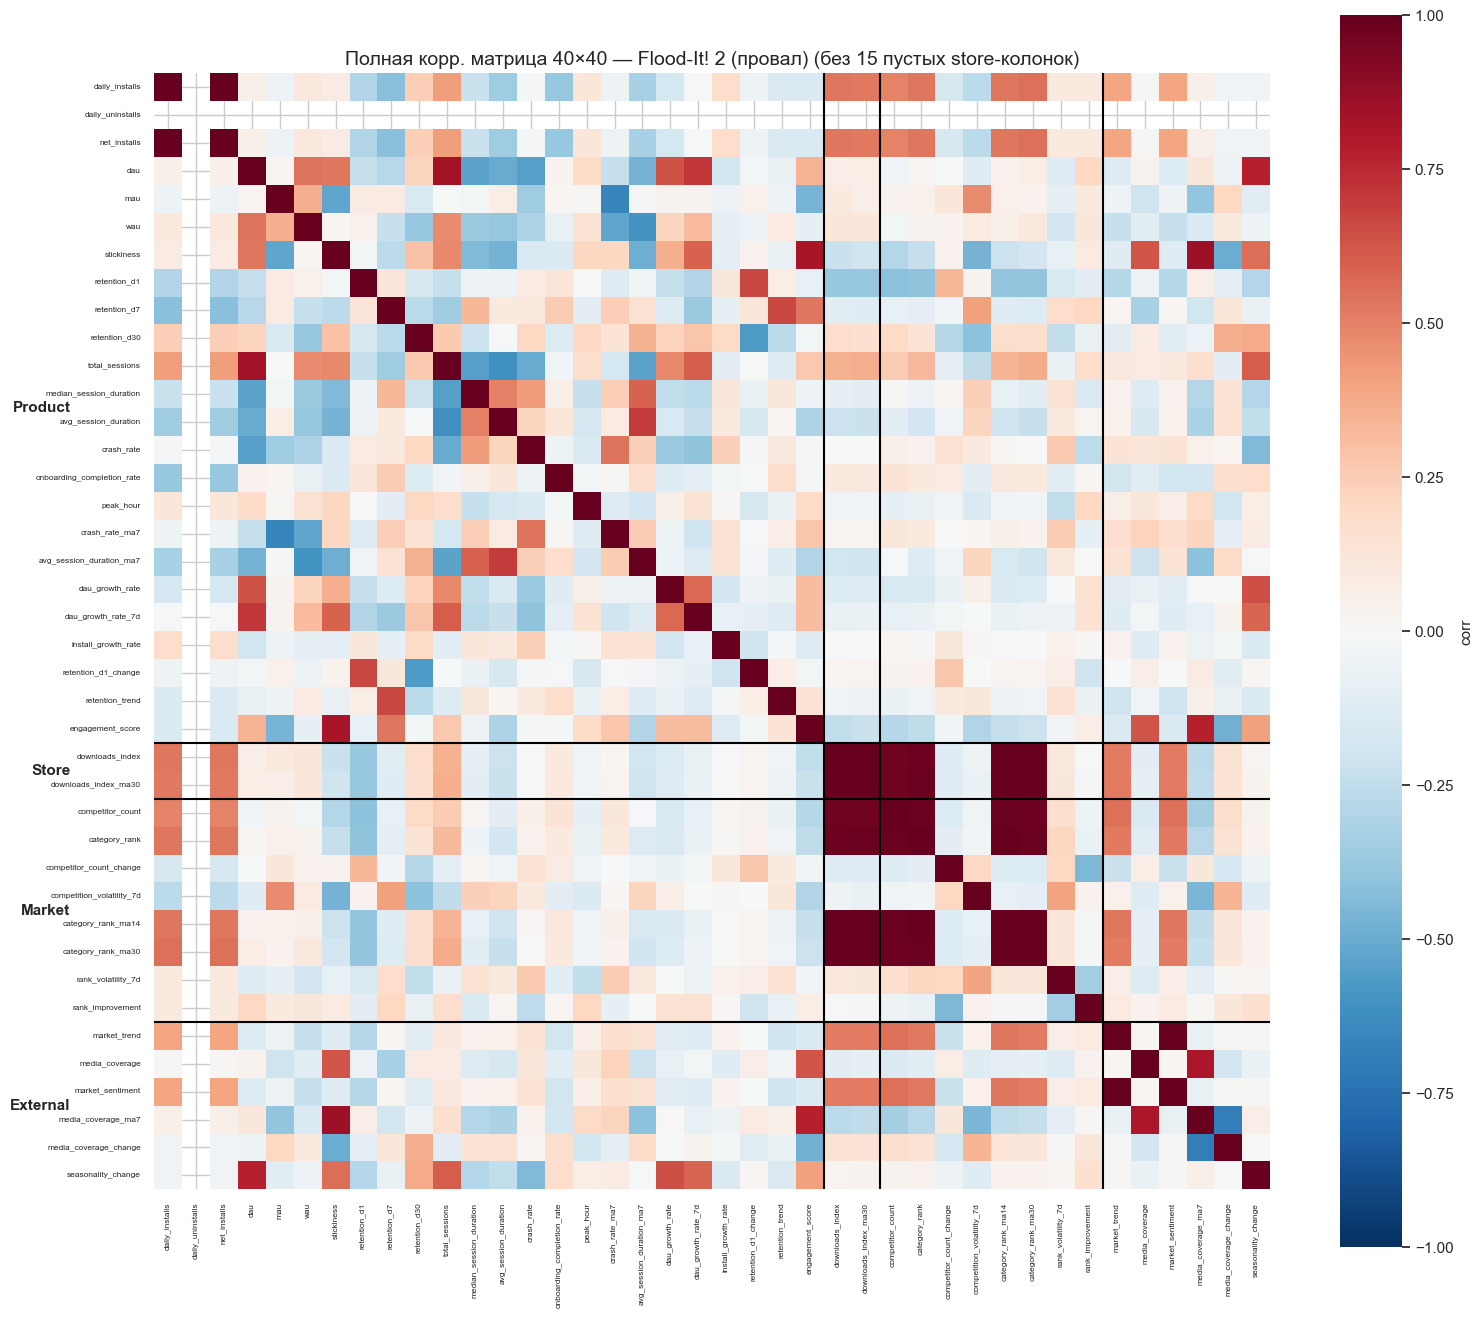

In [18]:
fig, ax = plt.subplots(figsize=(18, 16))
corr_full = df_f2[NON_EMPTY_FEATURES].corr()
sns.heatmap(corr_full, cmap="RdBu_r", center=0, annot=False, vmin=-1, vmax=1,
            square=True, ax=ax, cbar_kws={"label": "corr"},
            xticklabels=NON_EMPTY_FEATURES, yticklabels=NON_EMPTY_FEATURES)
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.tick_params(axis="y", labelsize=6)

# Source-group separators (учитываем что Store=2 DAU-derived)
n_p = len(PRODUCT_COLS)
n_s = len(DAU_DERIVED_STORE)
n_m = len(MARKET_COLS)
n_e = len(EXTERNAL_COLS)
group_boundaries = [n_p, n_p + n_s, n_p + n_s + n_m]
group_centers = [
    n_p / 2,
    n_p + n_s / 2,
    n_p + n_s + n_m / 2,
    n_p + n_s + n_m + n_e / 2,
]
group_names = ["Product", "Store", "Market", "External"]

for boundary in group_boundaries:
    ax.axhline(boundary, color="black", linewidth=1.5)
    ax.axvline(boundary, color="black", linewidth=1.5)

for center, name in zip(group_centers, group_names):
    ax.text(-3, center, name, ha="right", va="center", fontsize=11, fontweight="bold")

ax.set_title(f"Полная корр. матрица {len(NON_EMPTY_FEATURES)}×{len(NON_EMPTY_FEATURES)} — "
             f"{app_label(APP_ID)} (без 15 пустых store-колонок)", fontsize=14)
save_figure("corr_full_40x40", NOTEBOOK_SLUG)
plt.show()

### 7.2. Сокращённая корр. матрица 20 ключевых признаков

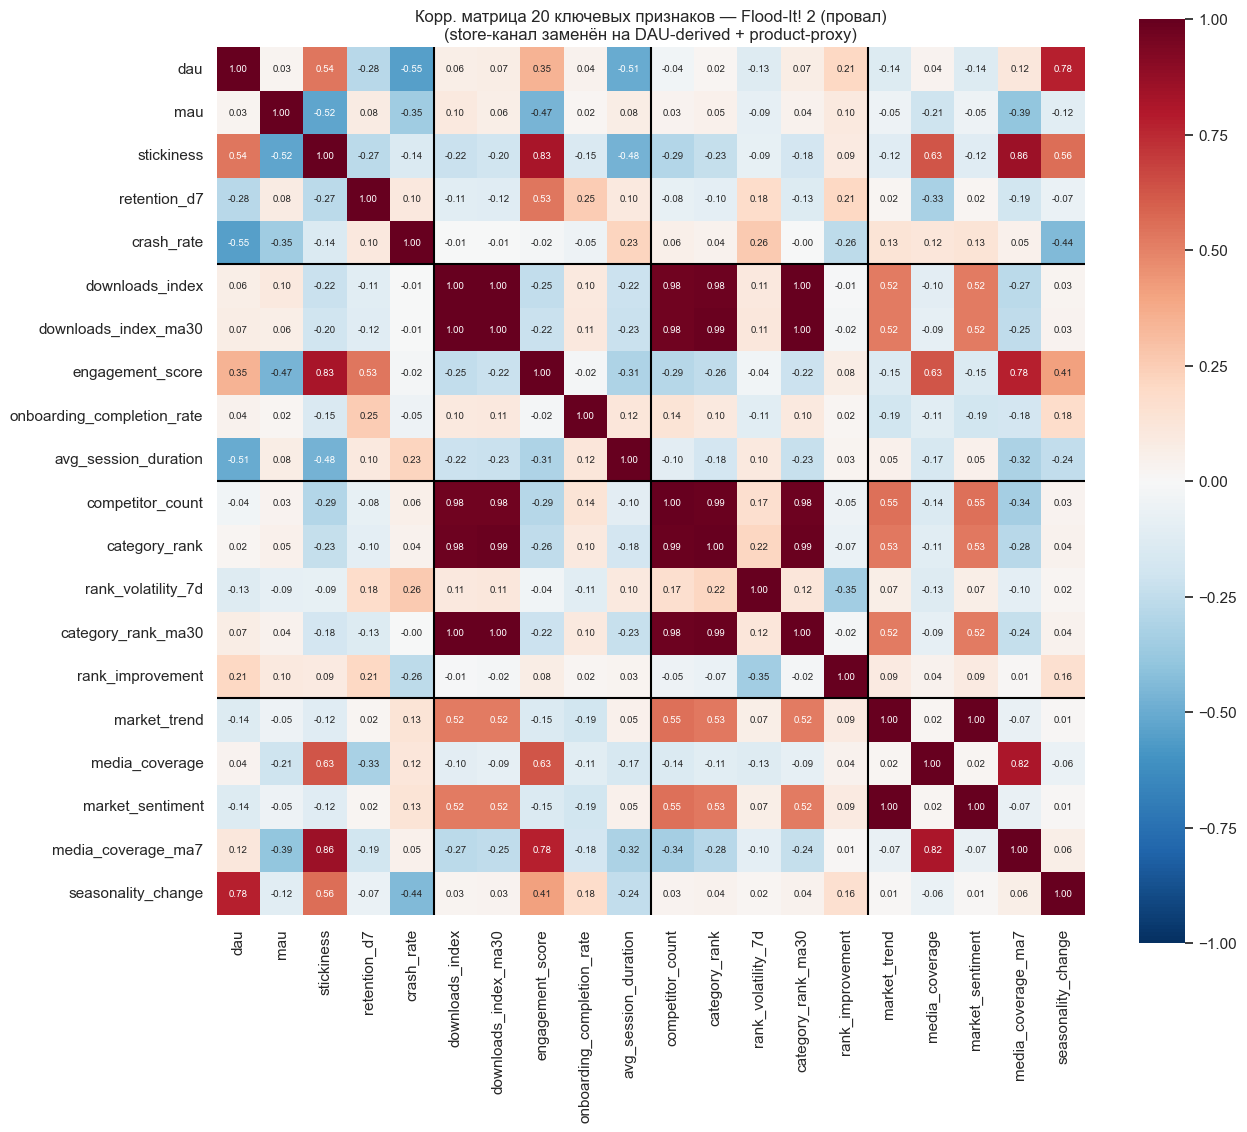

In [19]:
# 5 ключевых из каждой группы (бизнес-важность)
# Store-key для f2 заменён на DAU-derived + product-проксис (rating/reviews_count = NaN)
KEY_PRODUCT = ["dau", "mau", "stickiness", "retention_d7", "crash_rate"]
# Только 2 DAU-derived есть; остальные 3 «псевдо-store» позиции заменяем на product-аналоги
KEY_STORE   = ["downloads_index", "downloads_index_ma30", "engagement_score",
               "onboarding_completion_rate", "avg_session_duration"]
KEY_MARKET  = ["competitor_count", "category_rank", "rank_volatility_7d",
               "category_rank_ma30", "rank_improvement"]
KEY_EXTERNAL = ["market_trend", "media_coverage", "market_sentiment",
                "media_coverage_ma7", "seasonality_change"]
KEY_20 = KEY_PRODUCT + KEY_STORE + KEY_MARKET + KEY_EXTERNAL
assert len(KEY_20) == 20

fig, ax = plt.subplots(figsize=(14, 12))
corr_key = df_f2[KEY_20].corr()
sns.heatmap(corr_key, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            vmin=-1, vmax=1, square=True, ax=ax,
            annot_kws={"size": 7})
group_boundaries_k = [5, 10, 15]
for boundary in group_boundaries_k:
    ax.axhline(boundary, color="black", linewidth=1.5)
    ax.axvline(boundary, color="black", linewidth=1.5)
ax.set_title(f"Корр. матрица 20 ключевых признаков — {app_label(APP_ID)}\n"
             f"(store-канал заменён на DAU-derived + product-proxy)",
             fontsize=12)
save_figure("corr_key_20x20", NOTEBOOK_SLUG)
plt.show()

### 7.3. VIF-анализ — мультиколлинеарность по 40 признакам

In [20]:
# Заполняем NaN медианой для VIF
df_f2_filled = df_f2[NON_EMPTY_FEATURES].replace([np.inf, -np.inf], np.nan).copy()
df_f2_filled = df_f2_filled.fillna(df_f2_filled.median(numeric_only=True))

vif_df = compute_vif(df_f2_filled)
print(f"Признаков всего: {len(vif_df)}")
print(f"С VIF > 10 (мультиколлинеарных): {(~vif_df['keep']).sum()}")
print(f"С VIF <= 10 (приемлемых):       {vif_df['keep'].sum()}")
display(vif_df.head(20))

Признаков всего: 39
С VIF > 10 (мультиколлинеарных): 19
С VIF <= 10 (приемлемых):       20


,feature,vif,keep
0,daily_installs,1.000000e+09,False
1,net_installs,1.000000e+09,False
2,market_trend,1.000000e+09,False
3,market_sentiment,1.000000e+09,False
4,category_rank_ma30,5.762992e+03,False
5,category_rank_ma14,2.281653e+03,False
6,category_rank,1.287313e+03,False
7,downloads_index_ma30,1.158121e+03,False
8,downloads_index,8.696224e+02,False
9,competitor_count,3.784943e+02,False


**Примечание:** `daily_uninstalls` для Flood-It! 2 = 0 на всех 111 днях (постоянная колонка) — `compute_vif()` автоматически исключает константные признаки. Поэтому VIF вычислен на 39, а не 40 признаках.


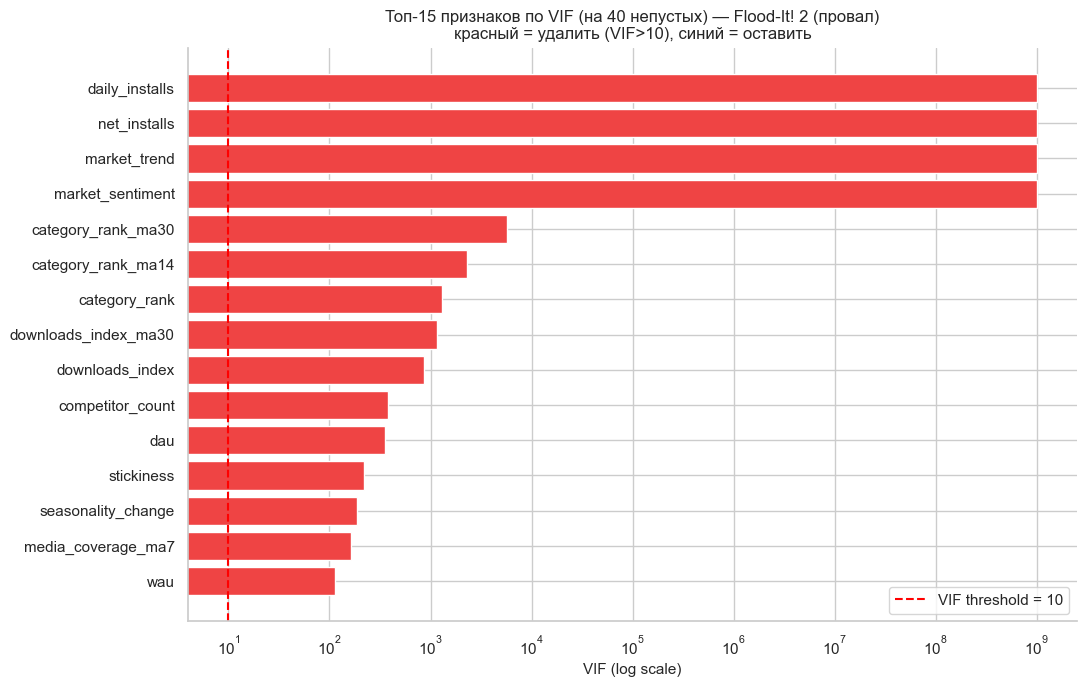

In [21]:
# Bar chart топ-15 по VIF
fig, ax = plt.subplots(figsize=(11, 7))
top15 = vif_df.head(15).copy()
colors = ["#ef4444" if not k else "#3b82f6" for k in top15["keep"]]
y = top15["feature"][::-1].values
x = top15["vif"][::-1].values
c = colors[::-1]
ax.barh(y, x, color=c)
ax.axvline(10, color="red", linestyle="--", label="VIF threshold = 10")
ax.set_xlabel("VIF (log scale)")
ax.set_xscale("log")
ax.set_title(f"Топ-15 признаков по VIF (на 40 непустых) — {app_label(APP_ID)}\n"
             f"красный = удалить (VIF>10), синий = оставить")
ax.legend(loc="lower right")
plt.tight_layout()
save_figure("vif_top15", NOTEBOOK_SLUG)
plt.show()

### 7.4. Топ-15 cross-source пар

In [22]:
def assign_group_f2(col):
    for group, cols in SOURCE_GROUPS_F2.items():
        if col in cols:
            return group
    return "Other"

cross_source_pairs = []
for c1, c2 in itertools.combinations(NON_EMPTY_FEATURES, 2):
    g1, g2 = assign_group_f2(c1), assign_group_f2(c2)
    if g1 != g2 and g1 != "Other" and g2 != "Other":
        r = corr_full.loc[c1, c2]
        if pd.notna(r) and abs(r) > 0.3:
            cross_source_pairs.append({
                "feat1": c1, "group1": g1,
                "feat2": c2, "group2": g2,
                "corr": round(float(r), 3),
            })

pairs_df = (
    pd.DataFrame(cross_source_pairs)
    .sort_values("corr", key=lambda s: s.abs(), ascending=False)
    .head(15)
    .reset_index(drop=True)
)
print(f"Всего cross-source пар с |corr|>0.3: {len(cross_source_pairs)}")
print(f"Топ-15:")
display(pairs_df)

Всего cross-source пар с |corr|>0.3: 75
Топ-15:


,feat1,group1,feat2,group2,corr
0,downloads_index_ma30,Store,category_rank_ma30,Market,0.998
1,downloads_index,Store,category_rank_ma30,Market,0.996
2,downloads_index_ma30,Store,category_rank_ma14,Market,0.994
3,downloads_index,Store,category_rank_ma14,Market,0.993
4,downloads_index_ma30,Store,category_rank,Market,0.985
5,downloads_index,Store,category_rank,Market,0.984
6,downloads_index,Store,competitor_count,Market,0.975
7,downloads_index_ma30,Store,competitor_count,Market,0.975
8,stickiness,Product,media_coverage_ma7,External,0.857
9,dau,Product,seasonality_change,External,0.780


In [23]:
# Распределение всех cross-source пар по парам групп
all_pairs_df = pd.DataFrame(cross_source_pairs)
if len(all_pairs_df) > 0:
    group_breakdown = all_pairs_df.groupby(["group1", "group2"]).agg(
        count=("corr", "size"),
        max_abs_corr=("corr", lambda x: x.abs().max()),
        mean_abs_corr=("corr", lambda x: x.abs().mean()),
    ).round(3).sort_values("count", ascending=False)
    display(group_breakdown)
print(f"\nИтого cross-source пар с |corr|>0.3: {len(all_pairs_df)}")

count  max_abs_corr  mean_abs_corr
group1  group2                                      
Product External     23         0.857          0.507
        Market       21         0.551          0.441
Market  External     11         0.554          0.491
Product Store         8         0.537          0.451
Store   Market        8         0.998          0.988
        External      4         0.520          0.519


Итого cross-source пар с |corr|>0.3: 75


### 7.5. Scatter plots топ-6 cross-source пар

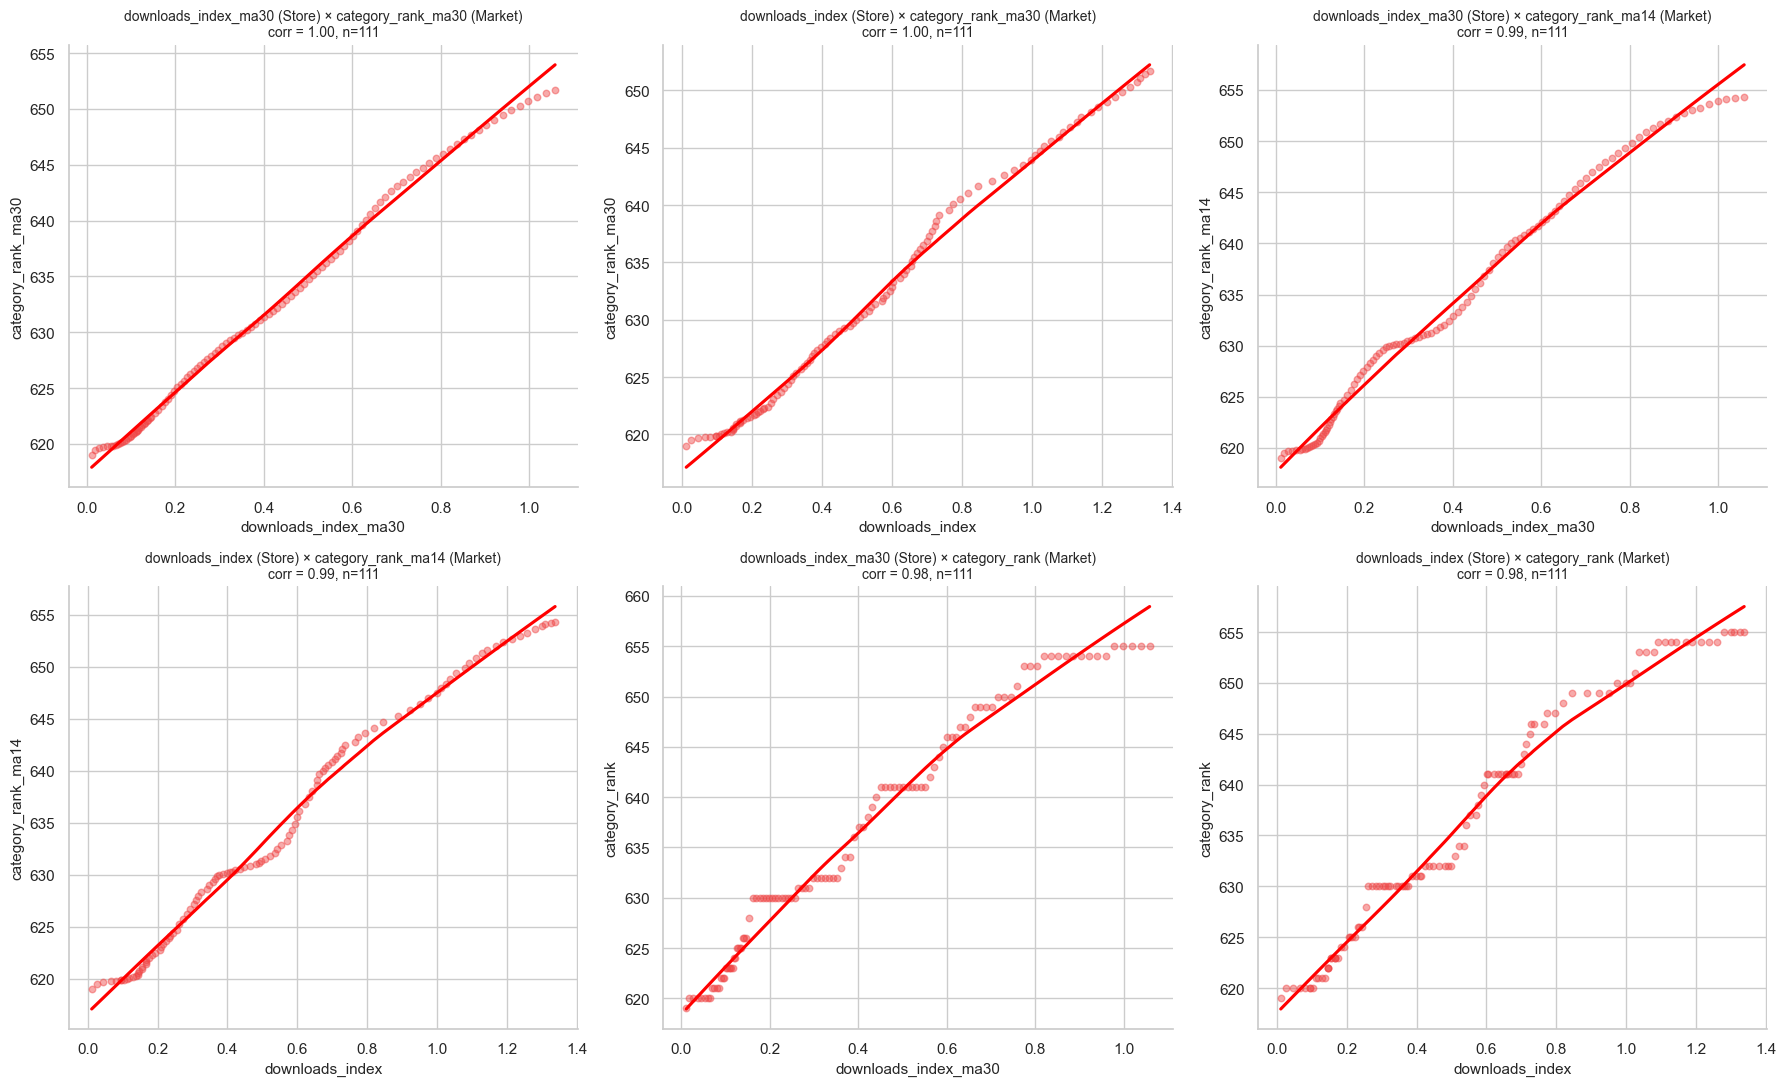

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
top6 = pairs_df.head(6).reset_index(drop=True)
for i, row in top6.iterrows():
    ax = axes.flat[i]
    sub = df_f2[[row["feat1"], row["feat2"]]].replace([np.inf, -np.inf], np.nan).dropna()
    sns.regplot(data=sub, x=row["feat1"], y=row["feat2"],
                lowess=True, scatter_kws={"alpha": 0.45, "s": 22, "color": APP_PALETTE[APP_ID]},
                line_kws={"color": "red"}, ax=ax)
    ax.set_title(f"{row['feat1']} ({row['group1']}) × {row['feat2']} ({row['group2']})\n"
                 f"corr = {row['corr']:.2f}, n={len(sub)}",
                 fontsize=10)
# Скрываем неиспользуемые subplots если top6 < 6
for j in range(len(top6), 6):
    axes.flat[j].set_visible(False)
plt.tight_layout()
save_figure("scatter_top6_cross_source", NOTEBOOK_SLUG)
plt.show()

### 7.6. Pairplot 6 ключевых таргет-метрик

У Flood-It! 2 `rating` целиком NaN (store снят), поэтому вместо `rating` используем `engagement_score` — product-сводную метрику вовлечённости.

Pairplot rows after dropna: 44/111


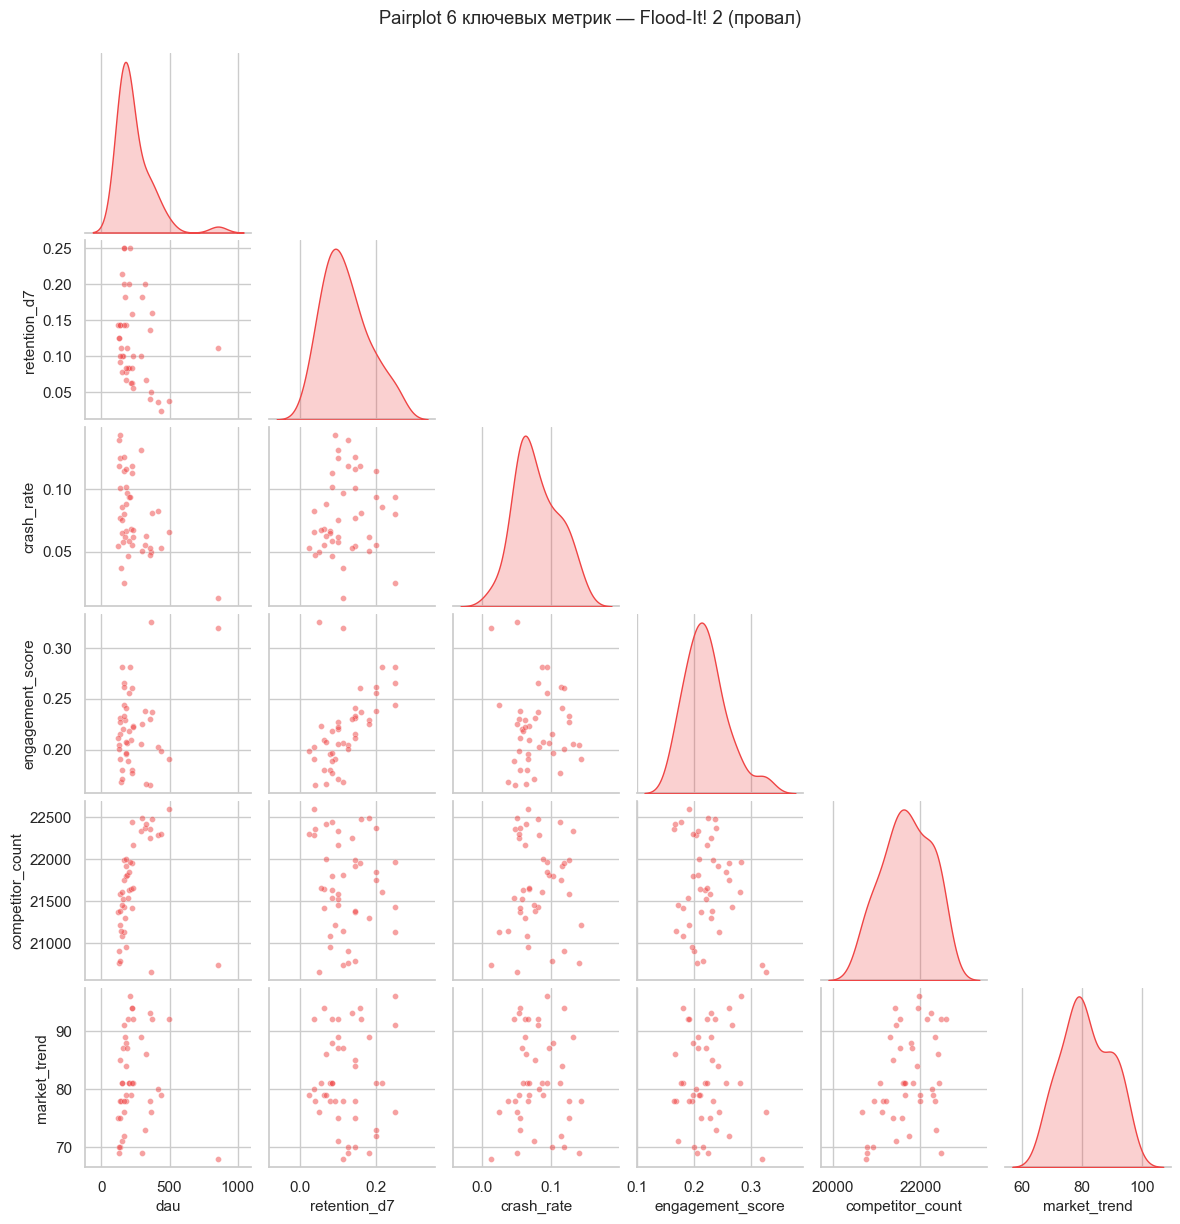

In [25]:
key6 = ["dau", "retention_d7", "crash_rate", "engagement_score", "competitor_count", "market_trend"]
df_pair = df_f2[key6].replace([np.inf, -np.inf], np.nan).dropna()
print(f"Pairplot rows after dropna: {len(df_pair)}/{len(df_f2)}")
g = sns.pairplot(df_pair, diag_kind="kde", height=2.0,
                 plot_kws={"alpha": 0.5, "s": 18, "color": APP_PALETTE[APP_ID]},
                 diag_kws={"color": APP_PALETTE[APP_ID]},
                 corner=True)
g.fig.suptitle(f"Pairplot 6 ключевых метрик — {app_label(APP_ID)}", y=1.02)
save_figure("pairplot_key6", NOTEBOOK_SLUG, fig=g.fig)
plt.show()

## 8. Объединённый time-series 5 ключевых метрик

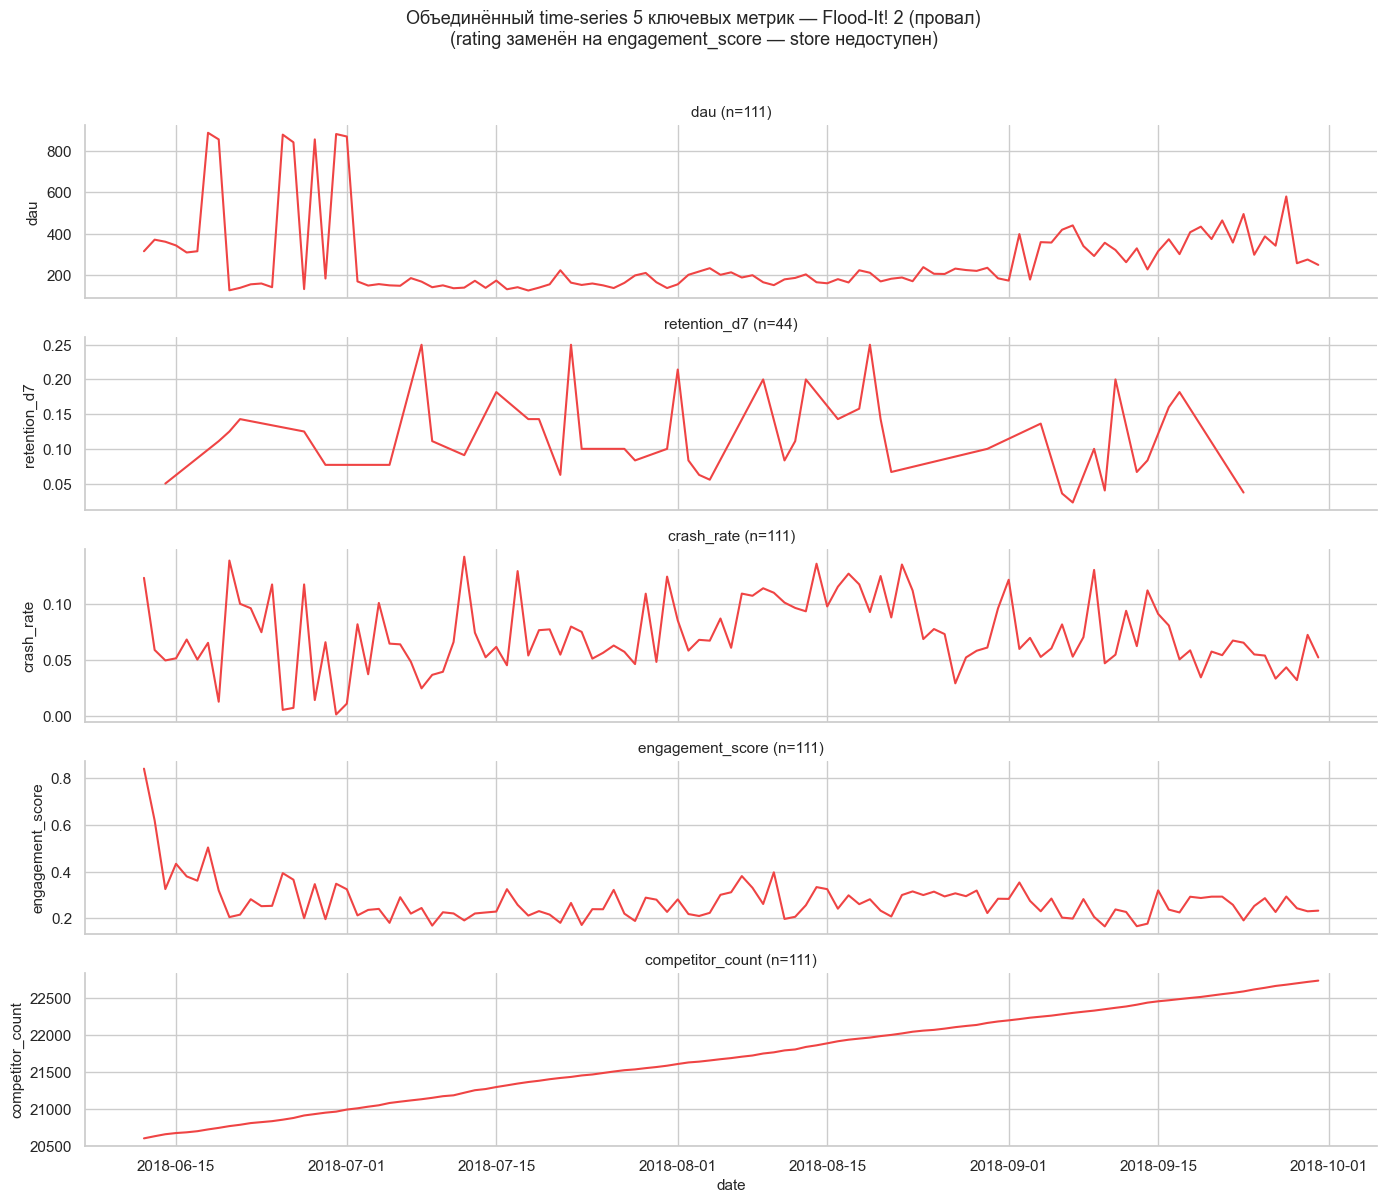

In [26]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
# rating заменён на engagement_score, т.к. rating целиком NaN для f2
metrics = ["dau", "retention_d7", "crash_rate", "engagement_score", "competitor_count"]
for i, m in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_f2, x="date", y=m, color=APP_PALETTE[APP_ID], ax=ax)
    ax.set_title(f"{m} (n={df_f2[m].notna().sum()})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel(m)
axes[-1].set_xlabel("date")
fig.suptitle(f"Объединённый time-series 5 ключевых метрик — {app_label(APP_ID)}\n"
             f"(rating заменён на engagement_score — store недоступен)",
             y=1.00, fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.98))
save_figure("unified_timeseries", NOTEBOOK_SLUG)
plt.show()

## 9. Выводы для Flood-It! 2

In [27]:
# Сводка реальных чисел для выводов
summary = {
    "dau_median": df_f2["dau"].median(),
    "dau_std": df_f2["dau"].std(),
    "stickiness_median": df_f2["stickiness"].median(),
    "stickiness_std": df_f2["stickiness"].std(),
    "retention_d7_median": df_f2["retention_d7"].median(),
    "retention_d7_n": df_f2["retention_d7"].notna().sum(),
    "crash_rate_median": df_f2["crash_rate"].median(),
    "crash_rate_pct_above_2pct": (df_f2["crash_rate"] > 0.02).mean() * 100,
    "onboarding_completion_median": df_f2["onboarding_completion_rate"].median(),
    "engagement_score_median": df_f2["engagement_score"].median(),
    "competitor_count_median": df_f2["competitor_count"].median(),
    "category_rank_median": df_f2["category_rank"].median(),
    "core_store_empty_count": len(CORE_STORE_COLS_EMPTY),
    "non_empty_features_count": len(NON_EMPTY_FEATURES),
    "vif_high_count": int((~vif_df["keep"]).sum()),
    "vif_keep_count": int(vif_df["keep"].sum()),
    "n_cross_source_pairs_above_0_3": len(cross_source_pairs),
}
if len(pairs_df) > 0:
    summary["top_pair"] = (pairs_df.iloc[0]["feat1"], pairs_df.iloc[0]["feat2"], pairs_df.iloc[0]["corr"])
for k, v in summary.items():
    print(f"{k}: {v}")

dau_median: 203.0
dau_std: 181.67512832595511
stickiness_median: 0.10740072202166065
stickiness_std: 0.1359398757462892
retention_d7_median: 0.10555555555555556
retention_d7_n: 44
crash_rate_median: 0.0663265306122449
crash_rate_pct_above_2pct: 94.5945945945946
onboarding_completion_median: 0.25462962962962965
engagement_score_median: 0.25578554178609336
competitor_count_median: 21688.0
category_rank_median: 632.0
core_store_empty_count: 15
non_empty_features_count: 40
vif_high_count: 19
vif_keep_count: 20
n_cross_source_pairs_above_0_3: 75
top_pair: ('downloads_index_ma30', 'category_rank_ma30', np.float64(0.998))


## 9. Выводы для Flood-It! 2

**Product-метрики (источник провала):**
- **DAU медиана = 203** (vs Flood-It! 275, −26%), std = 181,7 — высокая относительная волатильность (коэффициент вариации 0,90 vs 0,29 у f1)
- **stickiness медиана = 0,107**, std = 0,136 — нестабильное удержание дневной аудитории
- **retention_d7 медиана = 0,106**, но валидных всего 44/111 (vs 75/111 у f1) — данные разреженные
- **crash_rate медиана = 0,066** (6,6%), но **94,6% дней превышают порог Google Play 2%** — техническая нестабильность
- **onboarding_completion = 0,255** (vs f1 0,46) — почти двукратное падение завершения первого опыта
- **engagement_score медиана = 0,256** — ниже среднего по индустрии

**Store-сигнал — отсутствует:**
- 15/17 store-колонок 100% NaN: продукт удалён со store, репутации нет
- Само отсутствие store-сигнала — ранний индикатор провала
- Доступны только 2 DAU-derived store-колонки (downloads_index, downloads_index_ma30)

**Cross-source структура связей (по 75 парам с |corr|>0.3):**
- **75 пар vs 249 у Flood-It!** (3× меньше) — провальный продукт имеет более слабую cross-source структуру
- Распределение по группам: Product×External 23 пары (max=0,857), Product×Market 21, Market×External 11, Product×Store 8, Store×Market 8 (max=0,998), Store×External 4
- **Ключевая особенность f2:** strong Product×External связи (`stickiness × media_coverage_ma7 = 0,857`) — не наблюдались у f1, что может говорить о том, что f2 был более чувствителен к внешним факторам, не имея собственной устойчивой динамики

**Multicollinearity (VIF):**
- 19 признаков с VIF > 10 (мультиколлинеарны), 20 признаков keep, всего 39 в VIF-матрице
- *Примечание:* `daily_uninstalls` = 0 для всех дней (продукт не удалялся как app, поскольку был снят со store) — постоянная колонка автоматически исключена из VIF, итого 39 вместо 40

**Главный нарратив провала:**
Flood-It! 2 идентифицируется как высокорисковый по сочетанию признаков:
1. Высокая волатильность DAU/stickiness — нестабильная аудитория
2. Низкий onboarding_completion — критическая воронка не работает
3. crash_rate систематически выше Google Play threshold
4. Отсутствие store-репутации — публично продукт не существует
5. Слабая cross-source структура — поведение продукта не интегрировано с рыночным контекстом

Эти сигналы доступны на ранних метриках и теоретически позволили бы прогнозной системе классифицировать f2 как высокорисковый ещё до фактического снятия с публикации.


## 10. Сохранённые фигуры

In [28]:
from notebooks._common import figures_dir
fig_dir = figures_dir(NOTEBOOK_SLUG)
print(f"Сохранённые фигуры в {fig_dir}:")
files = sorted(fig_dir.glob("*.pdf"))
for p in files:
    print(f"  - {p.name}")
print(f"\nИтого: {len(files)} PDF")

Сохранённые фигуры в C:\7 семестр\пиздец\figures\02_eda_floodit2:
  - corr_full_40x40.pdf
  - corr_key_20x20.pdf
  - corr_product.pdf
  - histograms_product.pdf
  - nan_heatmap.pdf
  - pairplot_key6.pdf
  - scatter_top6_cross_source.pdf
  - timeseries_external_for_f2.pdf
  - timeseries_market_for_f2.pdf
  - timeseries_product.pdf
  - timeseries_store_partial.pdf
  - unified_timeseries.pdf
  - vif_top15.pdf

Итого: 13 PDF
